# Patient Clustering Project

### Contents:

#### 1- Understanding the data
#### 2- Cleaning 
#### 3- Null value processing
#### 4- Encoding
#### 5- Normalization (standart scaling and min-max scaling)
#### 6- Dimension Reductioning (PCA)
#### 7- Modelling (KMeans - Hierarchical - DBSCAN Clustering)
#### 8- Model Optimizing
#### 9- Model Conclusions
#### 10- Clustering Results in DataFrame

In [4]:
# IMID Multimorbidity Clustering and Longitudinal Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from xgboost import XGBClassifier, XGBRegressor

In [5]:
# Load dataset
data = pd.read_csv("patient_dataset.csv")
df = data.copy()


In [6]:
# --- Initial Inspection ---
print("\nInitial Dataset Info:\n")
df.info()
print(df.describe().T)


Initial Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                6000 non-null   int64  
 1   gender             5528 non-null   float64
 2   chest_pain_type    6000 non-null   int64  
 3   blood_pressure     6000 non-null   int64  
 4   cholesterol        6000 non-null   int64  
 5   max_heart_rate     6000 non-null   int64  
 6   exercise_angina    6000 non-null   int64  
 7   plasma_glucose     5391 non-null   float64
 8   skin_thickness     5386 non-null   float64
 9   insulin            5432 non-null   float64
 10  bmi                6000 non-null   float64
 11  diabetes_pedigree  6000 non-null   float64
 12  hypertension       6000 non-null   int64  
 13  heart_disease      6000 non-null   int64  
 14  residence_type     5545 non-null   object 
 15  smoking_status     6000 non-null   object 
dtype

# Understanding - Cleaning - Preprocessing

In [42]:
# --- Label Encoding ---
le = LabelEncoder()
df["smoking_status"] = le.fit_transform(df["smoking_status"])
df["residence_type"] = df["residence_type"].map({'Urban': 1, 'Rural': 0})

if not df["residence_type"].mode().empty:
    df["residence_type"] = df["residence_type"].fillna(df["residence_type"].mode()[0])
else:
    df["residence_type"] = df["residence_type"].fillna(1)  # Assume Urban

In [44]:
# --- Imputation using XGBoost ---
data = df.drop(["gender", "residence_type"], axis=1)
columns_with_nulls = data.columns[data.isnull().any()].tolist()

In [46]:
for column in columns_with_nulls:
    train_data = data[data[column].notnull()]
    X_train = train_data.drop(columns_with_nulls, axis=1)
    y_train = train_data[column]
    test_data = data[data[column].isnull()]
    X_test = test_data.drop(columns_with_nulls, axis=1)
    xgb = XGBRegressor()
    xgb.fit(X_train, y_train)
    data.loc[data[column].isnull(), column] = xgb.predict(X_test)


In [48]:
# Combine back the dropped columns
df_combined = pd.concat([df[["gender", "residence_type"]], data], axis=1)
data = df_combined.copy()


In [50]:
# --- Final Check for Nulls ---
print("\nFinal Dataset Info After Imputation:\n")
print(data.isnull().sum())


Final Dataset Info After Imputation:

gender               472
residence_type         0
age                    0
chest_pain_type        0
blood_pressure         0
cholesterol            0
max_heart_rate         0
exercise_angina        0
plasma_glucose         0
skin_thickness         0
insulin                0
bmi                    0
diabetes_pedigree      0
hypertension           0
heart_disease          0
smoking_status         0
dtype: int64


In [54]:
data["gender"] = data["gender"].fillna(data["gender"].mode()[0])

In [56]:
# --- Final Check for Nulls ---
print("\nFinal Dataset Info After Imputation:\n")
print(data.isnull().sum())


Final Dataset Info After Imputation:

gender               0
residence_type       0
age                  0
chest_pain_type      0
blood_pressure       0
cholesterol          0
max_heart_rate       0
exercise_angina      0
plasma_glucose       0
skin_thickness       0
insulin              0
bmi                  0
diabetes_pedigree    0
hypertension         0
heart_disease        0
smoking_status       0
dtype: int64


In [58]:
# --- Simulate IMID and Comorbidity Data ---
np.random.seed(42)
data['RA'] = np.random.binomial(1, 0.3, data.shape[0])
data['Lupus'] = np.random.binomial(1, 0.2, data.shape[0])
data['PsA'] = np.random.binomial(1, 0.25, data.shape[0])
data['Hypertension'] = np.random.binomial(1, 0.4, data.shape[0])
data['Diabetes'] = np.random.binomial(1, 0.35, data.shape[0])
data['Depression'] = np.random.binomial(1, 0.3, data.shape[0])

In [60]:
# --- Add Longitudinal Component ---
data['visit_month'] = np.random.randint(1, 13, data.shape[0])
data['disease_progression'] = data[['RA', 'Lupus', 'PsA']].sum(axis=1) + np.random.normal(0, 1, data.shape[0])


In [62]:
# --- Scale Data ---
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.select_dtypes(include=np.number))

In [64]:
# --- PCA for Visualization ---
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)
print("\nExplained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.07935732 0.07862074]


In [70]:
# --- Clustering Using KMeans ---
k_range = range(2, 11)
silhouette_scores = []

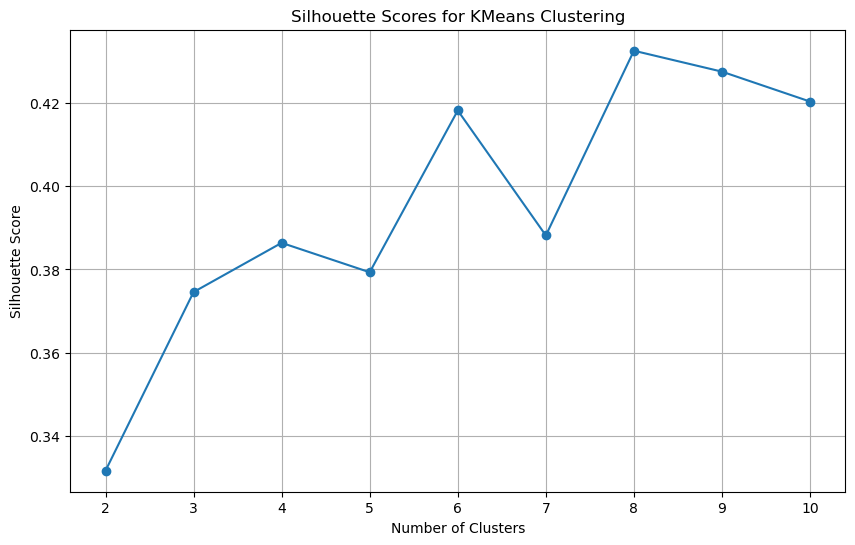

In [68]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_pca)
    score = silhouette_score(data_pca, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Scores for KMeans Clustering')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid()
plt.show()


In [72]:
# --- Apply Final Clustering (Choose optimal k, say k=3) ---
kmeans = KMeans(n_clusters=3, random_state=42)
data['trajectory_cluster'] = kmeans.fit_predict(data[['visit_month', 'disease_progression']])

In [86]:
df["residence_type"].unique()

array([1.])

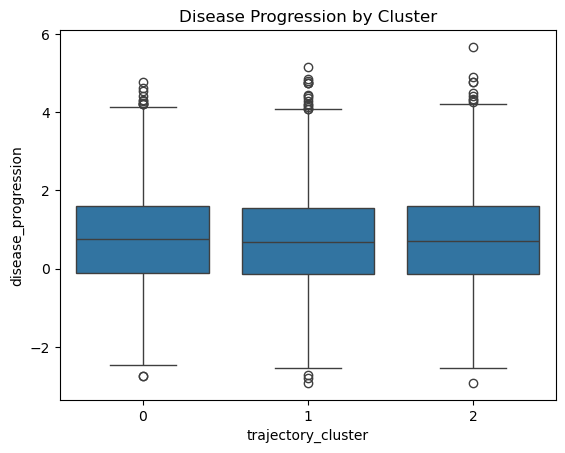

In [80]:
# --- Visualization of Clustering ---
sns.boxplot(x='trajectory_cluster', y='disease_progression', data=data)
plt.title("Disease Progression by Cluster")
plt.show()

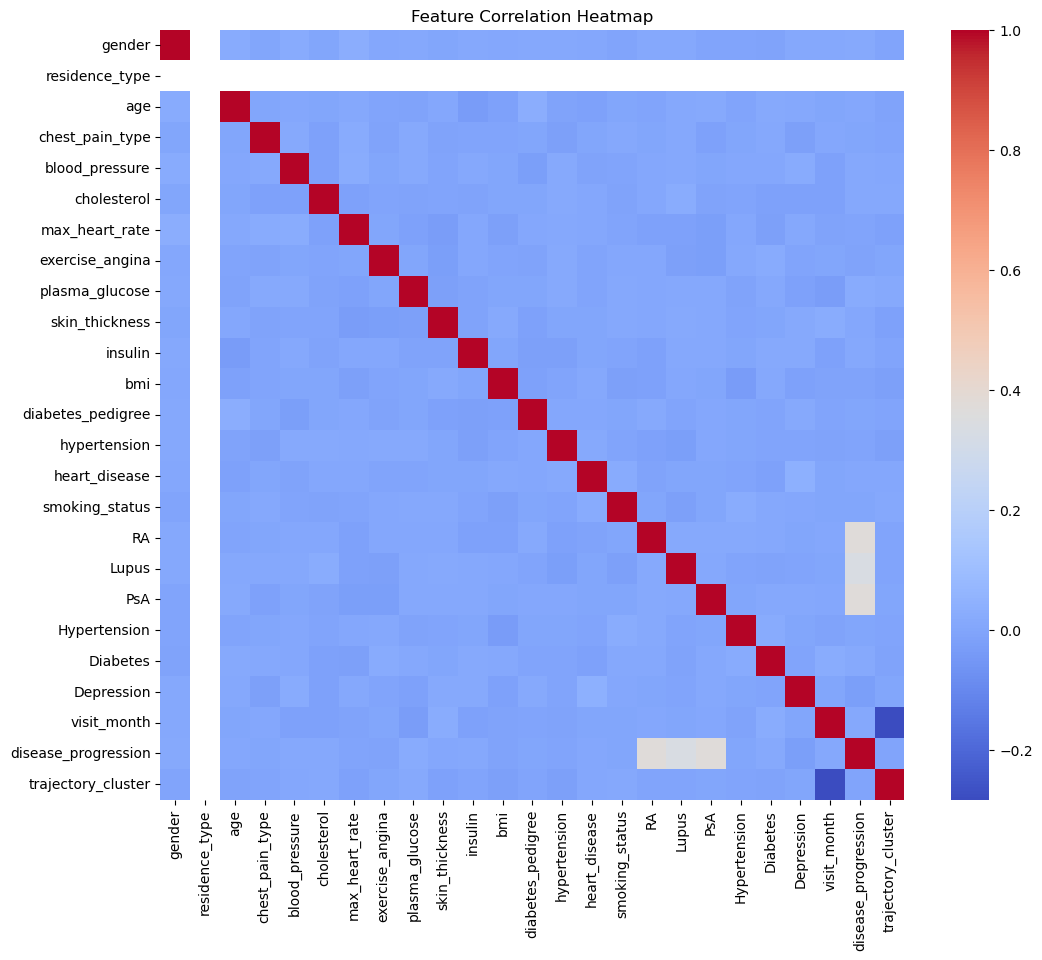

In [82]:
# --- Correlation Heatmap ---
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [84]:
print("\nCluster distribution:\n")
print(data['trajectory_cluster'].value_counts())


Cluster distribution:

trajectory_cluster
1    2526
2    2044
0    1430
Name: count, dtype: int64
